# Multiple Linear Regression

This notebook demonstrates Multiple Linear Regression using the PlacementPredict dataset.

### Objective

To predict the Salary Package using multiple independent variables:

- CGPA
- AptitudeTestScore
- SoftSkillsRating
- CodingTestScore
- MockInterviewScore

### Input (X)
CGPA, AptitudeTestScore, SoftSkillsRating, CodingTestScore, MockInterviewScore

### Output (Y)
Salary Package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv('C:\\Users\\vippa\\OneDrive\\Desktop\\KLH\\ML\\Placement Prediction\\data\\Prediction.csv')

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 50000
Number of columns: 32

Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Missing values:
StudentID                0
Gender                   0
City                     0
CollegeTier              0
Stream                   0
Specialisation           0
Hostel                   0
HistoryOfBacklogs        0
SGPA_Sem1                0
SGPA_Sem2                0
SGPA_Sem3                0
SGPA_Sem4                0
SGPA_Sem5                0
SGPA_Sem6                0
SGPA_Sem7                0
SGPA_Sem8                0
CGPA           

In [5]:
placed_df = df[df["Salary Package"] > 0].copy()

print("Total students:", len(df))
print("Placed students with Salary Package > 0:", len(placed_df))

Total students: 50000
Placed students with Salary Package > 0: 32924


## Select Input and Output Variables

The five independent variables are:

- CGPA
- AptitudeTestScore
- SoftSkillsRating
- CodingTestScore
- MockInterviewScore

The dependent variable is:

- Salary Package

In [6]:
features = [
    "CGPA",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

target = "Salary Package"

mlr_df = placed_df[features + [target]].copy()

print("Selected columns:")
print(mlr_df.columns.tolist())

display(mlr_df.head())

Selected columns:
['CGPA', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'Salary Package']


,CGPA,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,Salary Package
2,5.52,73.8,2.8,67.7,41.5,3.89
3,7.51,69.8,2.7,66.9,48.0,8.37
4,8.65,73.1,2.1,71.7,61.7,18.99
5,10.00,81.5,3.9,NaN,75.3,18.17
6,9.35,76.5,4.6,83.0,61.5,25.52


In [7]:
print("Missing values before removing:")
print(mlr_df.isnull().sum())

mlr_df = mlr_df.dropna()

print("\nRows after removing missing values:", len(mlr_df))

print("\nMissing values after removing:")
print(mlr_df.isnull().sum())

Missing values before removing:
CGPA                     0
AptitudeTestScore     2602
SoftSkillsRating      2303
CodingTestScore       1951
MockInterviewScore    3246
Salary Package           0
dtype: int64

Rows after removing missing values: 23875

Missing values after removing:
CGPA                  0
AptitudeTestScore     0
SoftSkillsRating      0
CodingTestScore       0
MockInterviewScore    0
Salary Package        0
dtype: int64


## Create X and y

X contains the five independent variables.

y contains the Salary Package, which is the dependent variable.

In [8]:
X = mlr_df[features]
y = mlr_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX:")
display(X.head())

print("\ny:")
display(y.head())

X shape: (23875, 5)
y shape: (23875,)

X:


,CGPA,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore
2,5.52,73.8,2.8,67.7,41.5
3,7.51,69.8,2.7,66.9,48.0
4,8.65,73.1,2.1,71.7,61.7
6,9.35,76.5,4.6,83.0,61.5
8,6.20,52.3,3.7,63.8,56.9



y:


2     3.89
3     8.37
4    18.99
6    25.52
8     5.51
Name: Salary Package, dtype: float64

##  Split the Dataset into Training and Testing Data

The dataset is divided into:

- 80% training data
- 20% testing data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 19100
Testing samples : 4775


##  Create the Multiple Linear Regression Model

A Multiple Linear Regression model is created using Scikit-learn's LinearRegression class.

In [10]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Model Coefficients

The model calculates one coefficient for each input variable.

The coefficients represent the contribution of each independent variable to the predicted Salary Package while considering the other variables in the model.

In [11]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(features, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: -22.747589962048355

Coefficients:
CGPA: 4.5978
AptitudeTestScore: -0.0619
SoftSkillsRating: 1.1420
CodingTestScore: -0.0787
MockInterviewScore: 0.1030


##  Multiple Linear Regression Equation

The general equation of Multiple Linear Regression is:

Salary Package = b0 + b1(CGPA) + b2(AptitudeTestScore) + b3(SoftSkillsRating) + b4(CodingTestScore) + b5(MockInterviewScore)

where:

- b0 is the intercept
- b1, b2, b3, b4 and b5 are the regression coefficients

In [12]:
print("Multiple Linear Regression Equation:\n")

print(f"Salary Package = {model.intercept_:.4f}")

for feature, coefficient in zip(features, model.coef_):
    print(f" + ({coefficient:.4f} × {feature})")

Multiple Linear Regression Equation:

Salary Package = -22.7476
 + (4.5978 × CGPA)
 + (-0.0619 × AptitudeTestScore)
 + (1.1420 × SoftSkillsRating)
 + (-0.0787 × CodingTestScore)
 + (0.1030 × MockInterviewScore)


## Make Predictions

The trained model is used to predict Salary Package for both training and testing data.

In [13]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


## Compare Actual and Predicted Values

The actual Salary Package values are compared with the values predicted by the model.

In [14]:
comparison = pd.DataFrame({
    "Actual Salary Package": y_test.values,
    "Predicted Salary Package": y_test_pred
})

display(comparison.head(10))

,Actual Salary Package,Predicted Salary Package
0,22.97,18.933874
1,5.88,5.370317
2,9.40,12.044234
3,25.14,23.806326
4,22.24,15.801024
5,25.35,25.683416
6,8.44,8.342422
7,8.84,11.380059
8,18.70,17.206504
9,18.70,20.242879


## Model Evaluation

The model is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [15]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R² Score:", r2)

Mean Squared Error (MSE): 16.438308013529358
Root Mean Squared Error (RMSE): 4.05441833232948
Mean Absolute Error (MAE): 3.262787677180636
R² Score: 0.6779957235259554


##  Actual vs Predicted Salary Package

Since Multiple Linear Regression uses five independent variables, an Actual vs Predicted plot is used to visualize model performance.

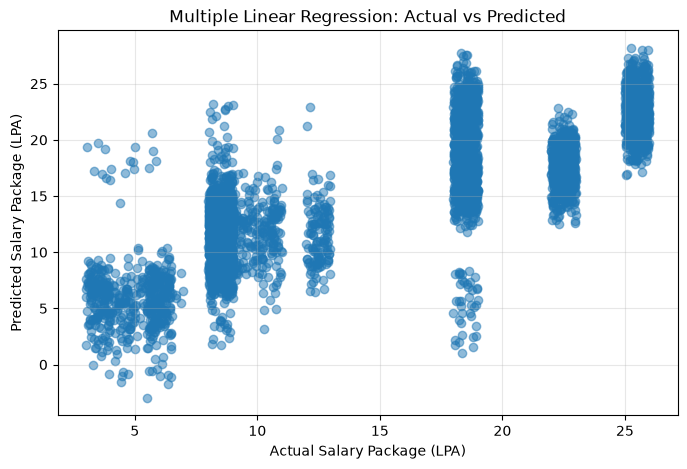

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

plt.xlabel("Actual Salary Package (LPA)")
plt.ylabel("Predicted Salary Package (LPA)")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.grid(True, alpha=0.3)
plt.show()

In [17]:
new_student = pd.DataFrame({
    "CGPA": [8.5],
    "AptitudeTestScore": [75],
    "SoftSkillsRating": [4.0],
    "CodingTestScore": [80],
    "MockInterviewScore": [75]
})

predicted_salary = model.predict(new_student)[0]

print(f"Predicted Salary Package: {predicted_salary:.2f} LPA")

Predicted Salary Package: 17.69 LPA
